<a href="https://colab.research.google.com/github/Noaman123-sam/project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

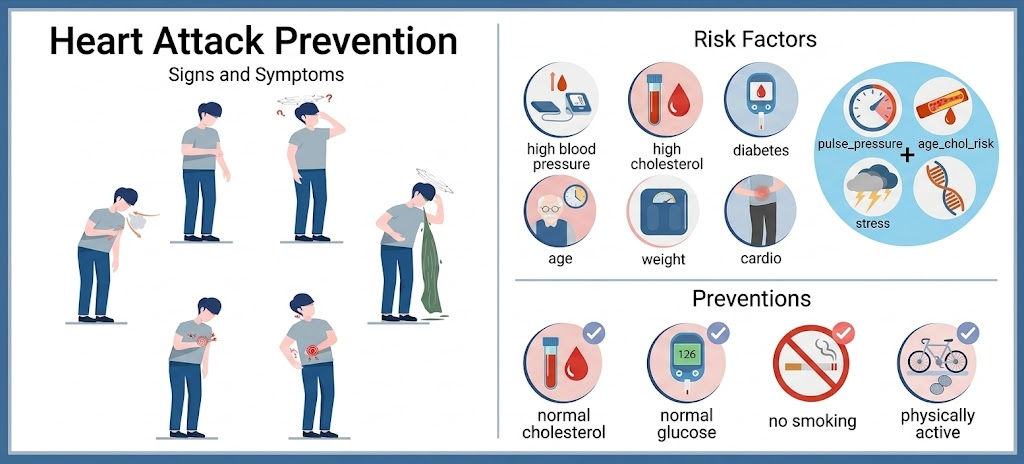

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [2]:

df = pd.read_csv('/content/cardio_train.csv', sep=';')

df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1



##  Detailed Data Dictionary

| Column Name | Description |
| :--- | :--- |
| <br>**AGE** | **Objective feature:** Age of the patient measured in **days**. |
| <br>**AGE_YEARS** | **Feature Engineering:** Age converted into **years** for better interpretation. |
| <br>**GENDER** | **Objective feature:** Gender of the patient (1: Women, 2: Men). |
| <br>**HEIGHT** | **Objective feature:** Height of the patient in **centimeters (cm)**. |
| <br>**WEIGHT** | **Objective feature:** Weight of the patient in **kilograms (kg)**. |
| <br>**AP_HI** | **Examination feature:** Systolic blood pressure (**Upper value**). |
| <br>**AP_LO** | **Examination feature:** Diastolic blood pressure (**Lower value**). |
| <br>**CHOLESTEROL** | **Examination feature:** Cholesterol level (1: normal, 2: above normal, 3: high). |
| <br>**GLUC** | **Examination feature:** Glucose level (1: normal, 2: above normal, 3: high). |
| <br>**SMOKE** | **Subjective feature:** Whether the patient smokes or not. |
| <br>**ALCO** | **Subjective feature:** Alcohol intake status. |
| <br>**ACTIVE** | **Subjective feature:** Physical activity status. |
| <br>**BMI** | **Feature Engineering:** Body Mass Index calculated as (Weight / Height²). |
| <br>**PULSE_PRESSURE** | **Feature Engineering:** The difference between Systolic and Diastolic BP. |
| <br>**BP_CATEGORY** | **Feature Engineering:** Blood pressure classification into medical stages. |
| <br>**CARDIO** | **Target Variable:** Presence or absence of cardiovascular disease (0: No, 1: Yes). |

#Check for missing values

In [3]:
df.isnull().sum().sort_values(ascending=False)

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


#check for Duplicated

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
df.drop('id', axis=1, inplace=True)

df['age'] = (df['age'] / 365).round().astype(int)

df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,48,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,61,1,163,72.0,135,80,1,2,0,0,0,1


# Outlier detection using Interquartile Range (IQR)

In [7]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    print(f"Column: {col:15} | Outliers: {outliers_count}")

Column: age             | Outliers: 4
Column: gender          | Outliers: 0
Column: height          | Outliers: 519
Column: weight          | Outliers: 1819
Column: ap_hi           | Outliers: 1435
Column: ap_lo           | Outliers: 4632
Column: cholesterol     | Outliers: 0
Column: gluc            | Outliers: 10521
Column: smoke           | Outliers: 6169
Column: alco            | Outliers: 3764
Column: active          | Outliers: 13739
Column: cardio          | Outliers: 0


#Target Distribution

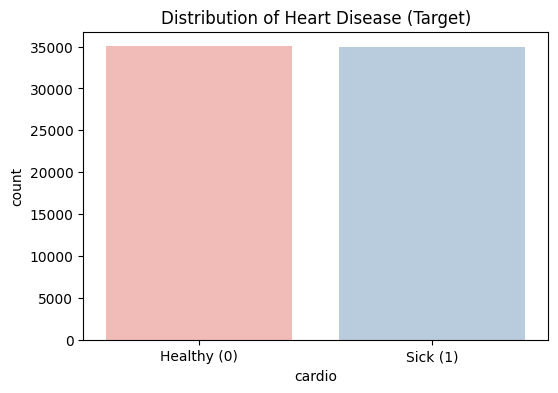

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', hue='cardio', data=df, palette='Pastel1', legend=False)
plt.title('Distribution of Heart Disease (Target)')
plt.xticks([0, 1], ['Healthy (0)', 'Sick (1)'])
plt.show()

##  Handling Outliers and Anomalies

In [9]:
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 150)]
df = df[df['ap_hi'] > df['ap_lo']]


df = df[(df['height'] >= df['height'].quantile(0.005)) & (df['height'] <= df['height'].quantile(0.995))]
df = df[(df['weight'] >= df['weight'].quantile(0.005)) & (df['weight'] <= df['weight'].quantile(0.995))]



#Feature Engineering

In [10]:


df['bmi'] = df['weight'] / (df['height'] / 100)**2


df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

df['high_blood_pressure'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)


df['age_chol_risk'] = df['age'] * df['cholesterol']


df['is_healthy'] = ((df['smoke'] == 0) & (df['alco'] == 0) & (df['active'] == 1) &
   (df['cholesterol'] == 1) & (df['gluc'] == 1)).astype(int)

print("Features Created Successfully!")
print(f"New Number of Features: {df.shape[1]}")

Features Created Successfully!
New Number of Features: 17


## Multivariate Analysis & Feature Relationship

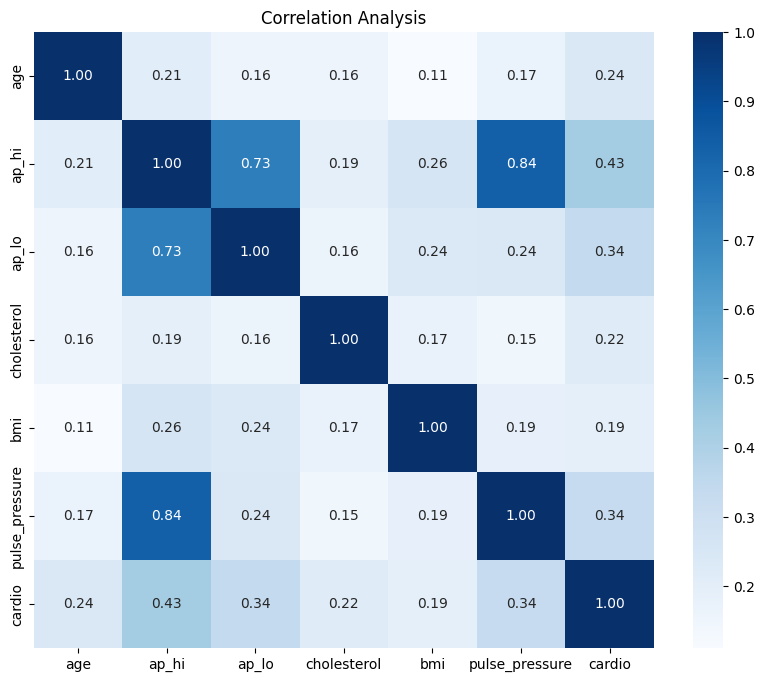

In [11]:
import seaborn as sns

top_features = ['age', 'ap_hi', 'ap_lo', 'cholesterol', 'bmi', 'pulse_pressure', 'cardio']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Analysis")
plt.show()

##  Categorical Encoding

In [12]:

df = pd.get_dummies(df, columns=['cholesterol', 'gluc'], prefix=['chol', 'gluc'])


df = df.astype(float)

print("Done! ")
print(df.head())

Done! 
    age  gender  height  weight  ap_hi  ap_lo  smoke  alco  active  cardio  \
0  50.0     2.0   168.0    62.0  110.0   80.0    0.0   0.0     1.0     0.0   
1  55.0     1.0   156.0    85.0  140.0   90.0    0.0   0.0     1.0     1.0   
2  52.0     1.0   165.0    64.0  130.0   70.0    0.0   0.0     0.0     1.0   
3  48.0     2.0   169.0    82.0  150.0  100.0    0.0   0.0     1.0     1.0   
4  48.0     1.0   156.0    56.0  100.0   60.0    0.0   0.0     0.0     0.0   

   ...  pulse_pressure  high_blood_pressure  age_chol_risk  is_healthy  \
0  ...            30.0                  0.0           50.0         1.0   
1  ...            50.0                  1.0          165.0         0.0   
2  ...            60.0                  0.0          156.0         0.0   
3  ...            50.0                  1.0           48.0         1.0   
4  ...            40.0                  0.0           48.0         0.0   

   chol_1  chol_2  chol_3  gluc_1  gluc_2  gluc_3  
0     1.0     0.0     0.0  

## Data Splitting && Scaling

In [13]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("Done!")

X_train shape: (54027, 20)
X_test shape: (13507, 20)
Done!


#Model Training before  Feature Selection

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
   "LightGBM": LGBMClassifier()
}


for name, model in models.items():
    print(f"--- Training {name} ---")


    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy for {name}: {acc * 100:.2f}%")
    print(f"Classification Report for {name}:\n{report}")
    print("="*50)

--- Training Logistic Regression ---
Accuracy for Logistic Regression: 72.78%
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.70      0.80      0.75      6842
         1.0       0.76      0.66      0.70      6665

    accuracy                           0.73     13507
   macro avg       0.73      0.73      0.73     13507
weighted avg       0.73      0.73      0.73     13507

--- Training Random Forest ---
Accuracy for Random Forest: 70.04%
Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.70      0.71      0.71      6842
         1.0       0.70      0.69      0.69      6665

    accuracy                           0.70     13507
   macro avg       0.70      0.70      0.70     13507
weighted avg       0.70      0.70      0.70     13507

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:16:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy for XGBoost: 72.80%
Classification Report for XGBoost:
              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74      6842
         1.0       0.74      0.68      0.71      6665

    accuracy                           0.73     13507
   macro avg       0.73      0.73      0.73     13507
weighted avg       0.73      0.73      0.73     13507

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 26720, number of negative: 27307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 791
[LightGBM] [Info] Number of data points in the train set: 54027, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494568 -> initscore=-0.021731
[LightGBM] [Info] Start training from score -0.021731
Accuracy for LightGBM: 73.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Finding the Optimal Number of Features (Feature Selection)

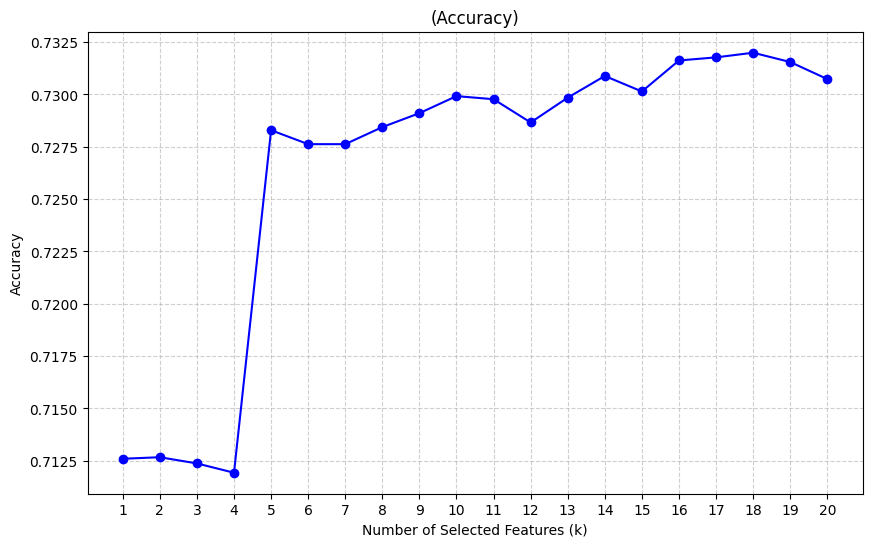

 18    73.20%


In [15]:
max_features = X_train_scaled.shape[1]
feature_counts = range(1, max_features + 1)

accuracies = []

for k in feature_counts:

    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_temp = selector.fit_transform(X_train_scaled, y_train)
    X_test_temp = selector.transform(X_test_scaled)


    model = XGBClassifier(n_estimators=50, max_depth=3, random_state=42)
    model.fit(X_train_temp, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_temp))
    accuracies.append(acc)


plt.figure(figsize=(10, 6))
plt.plot(list(feature_counts), accuracies, marker='o', linestyle='-', color='b')
plt.title('(Accuracy)')
plt.xlabel('Number of Selected Features (k)')
plt.ylabel('Accuracy')
plt.xticks(list(feature_counts))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

best_k = feature_counts[np.argmax(accuracies)]
print(f" {best_k}    {max(accuracies)*100:.2f}%")

#Feature Selection

In [16]:
selector = SelectKBest(score_func=f_classif, k=13)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)





all_features = X_train.columns
selected_indices = selector.get_support(indices=True)
selected_features_names = all_features[selected_indices].tolist()
print(f"Selected {len(selected_features_names)} Features:")
for i, feature in enumerate(selected_features_names, 1):
    print(f"{i}. {feature}")


import pandas as pd
feature_scores = pd.DataFrame({'Feature': all_features, 'Score': selector.scores_})
print("\n Feature Scores (Top 13):")
print(feature_scores.sort_values(by='Score', ascending=False).head(13))




Selected 13 Features:
1. age
2. weight
3. ap_hi
4. ap_lo
5. bmi
6. pulse_pressure
7. high_blood_pressure
8. age_chol_risk
9. is_healthy
10. chol_1
11. chol_2
12. chol_3
13. gluc_1

 Feature Scores (Top 13):
                Feature         Score
4                 ap_hi  12118.994091
11  high_blood_pressure  11016.493840
5                 ap_lo   7092.457542
10       pulse_pressure   6893.858829
12        age_chol_risk   3774.525556
0                   age   3361.570594
14               chol_1   2363.466196
16               chol_3   2097.962340
9                   bmi   2088.158158
3                weight   1824.576126
13           is_healthy   1133.698923
17               gluc_1    478.992751
15               chol_2    341.136051


#Model Training After Feature Selection

In [17]:
from sklearn.metrics import accuracy_score, f1_score



final_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    subsample=0.8,
    random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.05)
}


print(f"{'Model':<25} | {'Accuracy':<10}")
print("-" * 40)

results = {}
for name, model in final_models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    results[name] = y_pred

    print(f"{name:<25} | {acc*100:.2f}%")

print("\n" + "="*40)
print(classification_report(y_test, results["Random Forest"]))
final_acc = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print(f" Final Model Performance:")
print(f"--- Accuracy: {final_acc*100:.2f}%")
print(f"--- F1-Score: {final_f1*100:.2f}%")

Model                     | Accuracy  
----------------------------------------
Logistic Regression       | 72.58%
Random Forest             | 72.75%
XGBoost                   | 72.85%
[LightGBM] [Info] Number of positive: 26720, number of negative: 27307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 729
[LightGBM] [Info] Number of data points in the train set: 54027, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494568 -> initscore=-0.021731
[LightGBM] [Info] Start training from score -0.021731
LightGBM                  | 72.75%

              precision    recall  f1-score   support

         0.0       0.71      0.78      0.74      6842
         1.0       0.75      0.67      0.71      6665

    accuracy                           0.73     13507
   m

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Model Performance Evaluation (Confusion Matrix)

<Figure size 800x600 with 0 Axes>

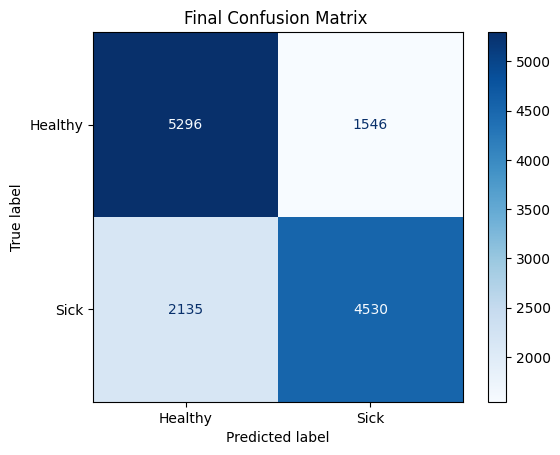

In [18]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Sick'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Final Confusion Matrix ')
plt.show()

##  Feature Impact & Global Correlation Analysis

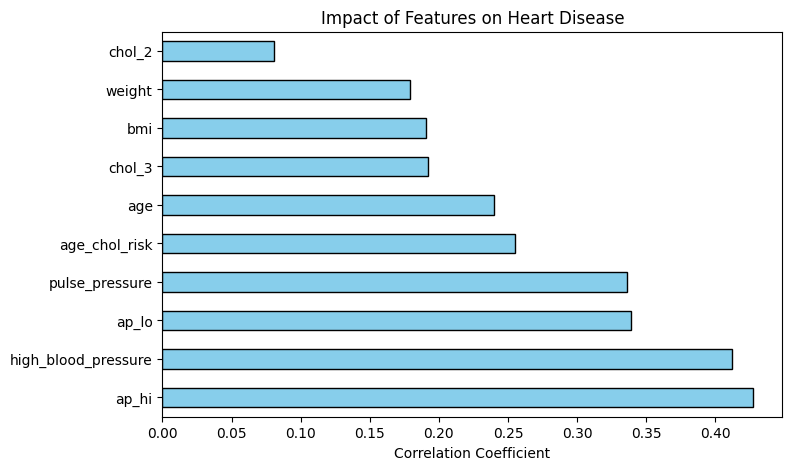

In [19]:
import matplotlib.pyplot as plt


main_features = ['age', 'ap_hi', 'ap_lo', 'chol_3', 'bmi', 'pulse_pressure', 'cardio','high_blood_pressure','age_chol_risk','weight','chol_2']

plt.figure(figsize=(8, 5))
feat_importances = df[main_features].corr()['cardio'].sort_values(ascending=False).drop('cardio')
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Impact of Features on Heart Disease')
plt.xlabel('Correlation Coefficient')
plt.show()

#Final Training & Model Exporting

In [21]:
from sklearn.preprocessing import StandardScaler
import joblib


selected_13 = ['age', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure',
               'high_blood_pressure', 'age_chol_risk', 'is_healthy',
               'chol_1', 'chol_2', 'chol_3', 'gluc_1']

X_train_final = X_train[selected_13]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)

final_model = LGBMClassifier(n_estimators=100, learning_rate=0.05)
final_model.fit(X_train_scaled, y_train)


joblib.dump(final_model, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selected_13, 'features_list.pkl')

print("done")

[LightGBM] [Info] Number of positive: 26720, number of negative: 27307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 729
[LightGBM] [Info] Number of data points in the train set: 54027, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494568 -> initscore=-0.021731
[LightGBM] [Info] Start training from score -0.021731
done
